# 🚀 Sistem Pembelajaran Adaptif Pintar: End-to-End ML & Graph Pipeline
**Proyek Akhir: Reasoning & Planning dalam AI**  
**Oleh Kelompok AI Learning Path:**
1. Vincentius Raynard Thedy (240028)
2. Tubagus Achmad Danial Ma’arief (240030)
3. Bagas Anung Bayu Nugraha (240046)

---

### 📌 Latar Belakang & Deskripsi Proyek
Proyek ini mengimplementasikan **sistem tutor pintar adaptif (Intelligent Tutoring System)** yang dirancang untuk mendeteksi risiko akademis mahasiswa sejak dini (*dropout prediction*) dan memberikan jalur rekomendasi belajar secara personal (*personalized learning path*). Proyek ini memanfaatkan dataset standar emas pendidikan: **OULAD (Open University Learning Analytics Dataset)**.

### 🧩 Arsitektur Pipeline Utama:
1. **Klasifikasi Risiko Dropout (Random Forest + SMOTE):** Memprediksi probabilitas kelulusan vs dropout mahasiswa berdasarkan pola interaksi VLE (*Virtual Learning Environment*) dan nilai asesmen awal.
2. **Peta Konsep & Jalur Belajar (NetworkX DAG):** Membangun Graf Berarah Bebas Siklus (*Directed Acyclic Graph*) untuk memodelkan prasyarat antar topik silabus dan mengurutkan materi menggunakan *Topological Sort*.
3. **Pelacakan Kemampuan Kognitif (Bayesian Knowledge Tracing - BKT):** Memprediksi probabilitas penguasaan konsep (*Mastery*) siswa secara *real-time* setelah menjawab kuis.
4. **Spaced Repetition (FSRS / SM-2):** Menjadwalkan waktu ulasan mandiri untuk materi yang telah dikuasai agar tidak cepat lupa berdasarkan kurva retensi memori.
5. **Dynamic Remedial Loops:** Merekayasa ulang struktur graf silabus secara dinamis untuk menyisipkan modul latihan remedial jika siswa mengalami kebuntuan belajar.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Library ML berhasil dimuat.")

Library ML berhasil dimuat.


## 🧹 Bab 1: Data Cleaning & Feature Engineering
---
### 📌 Penjelasan Langkah:
Pada tahap ini, kita mengekstrak fitur perilaku dari data mentah OULAD untuk dijadikan input model prediktif. Dua fitur utama yang dibentuk adalah:
1. **`sum_click` (Keterlibatan VLE):** Menjumlahkan total aktivitas klik mahasiswa pada media pembelajaran elektronik (*Virtual Learning Environment*). Fitur ini mengukur intensitas interaksi belajar.
2. **`avg_score` (Performa Akademis):** Menghitung rata-rata nilai asesmen (*assessment*) mahasiswa. Nilai ini menjadi indikator langsung tingkat pemahaman awal akademis.

### 🎯 Tujuan Presentasi:
Menunjukkan bagaimana data transaksional mentah yang sangat besar (lebih dari 10 juta baris pada `studentVle.csv`) dapat diringkas menjadi fitur level-mahasiswa yang bermakna bagi algoritma machine learning.


In [2]:
# 1.1 Memuat Dataset OULAD
data_dir = '../dataset/'

print("Membaca dataset OULAD...")
student_info = pd.read_csv(data_dir + 'studentInfo.csv')
# Menggunakan subset agar pemrosesan memori efisien saat presentasi
student_vle = pd.read_csv(data_dir + 'studentVle.csv', nrows=1000000) 
student_assessment = pd.read_csv(data_dir + 'studentAssessment.csv')

# 1.2 Feature Engineering 1: Total Aktivitas VLE (Klik)
vle_agg = student_vle.groupby('id_student')['sum_click'].sum().reset_index()

# 1.3 Feature Engineering 2: Performa Ujian (Assessment)
# Rata-rata skor mahasiswa
assessment_agg = student_assessment.groupby('id_student')['score'].mean().reset_index()
assessment_agg.rename(columns={'score': 'avg_score'}, inplace=True)

# Menggabungkan fitur ke tabel utama
df = pd.merge(student_info, vle_agg, on='id_student', how='left')
df = pd.merge(df, assessment_agg, on='id_student', how='left')

# 1.4 Missing Value Handling
# Mengisi fitur numerik yang kosong dengan 0 (artinya tidak ada klik/tidak ikut ujian)
df['sum_click'] = df['sum_click'].fillna(0)
df['avg_score'] = df['avg_score'].fillna(0)

# Mengisi fitur kategorikal dengan modus (MCAR/MAR Strategy)
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

print("Sampel Data dengan Fitur Baru:")
display(df[['id_student', 'sum_click', 'avg_score', 'final_result']].head(5))


Membaca dataset OULAD...
Sampel Data dengan Fitur Baru:


,id_student,sum_click,avg_score,final_result
0,11391,934.0,82.0,Pass
1,28400,1435.0,66.4,Pass
2,30268,281.0,0.0,Withdrawn
3,31604,2158.0,76.0,Pass
4,32885,1034.0,54.4,Pass


In [3]:
# 1.5 Categorical Encoding
# Target (Label): Sederhanakan kelulusan menjadi klasifikasi Biner (Lulus vs Gagal)
def map_target(res):
    if res in ['Pass', 'Distinction']: return 1 # Lulus
    else: return 0 # Gagal / Dropout

df['target'] = df['final_result'].apply(map_target)

# Ordinal Encoding untuk pendidikan tertinggi
edu_mapping = {'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2, 'HE Qualification': 3, 'Post Graduate Qualification': 4}
df['education_encoded'] = df['highest_education'].map(edu_mapping)

# Tentukan Fitur Pemodelan (X)
X = df[['sum_click', 'avg_score', 'studied_credits', 'education_encoded', 'num_of_prev_attempts']]
y = df['target']


## ⚖️ Bab 2: Splitting & Penanganan Imbalance Data (SMOTE)
---
### 📌 Penjelasan Langkah:
Dataset pendidikan sering kali tidak seimbang (*imbalanced*), di mana jumlah mahasiswa yang lulus jauh lebih banyak daripada yang putus sekolah (*dropout*). Jika dibiarkan, model akan cenderung condong memprediksi kelas mayoritas (Lulus) dan gagal mendeteksi mahasiswa yang berisiko dropout.

Untuk mengatasinya, kita menggunakan **SMOTE (Synthetic Minority Over-sampling Technique)**. Algoritma ini bekerja dengan membuat sampel sintetis baru untuk kelas minoritas (Dropout) menggunakan interpolasi K-Nearest Neighbors (KNN):

$$x_{baru} = x_i + \lambda(x_{zi} - x_i)$$

Di mana $x_i$ adalah sampel minoritas, $x_{zi}$ adalah salah satu tetangga terdekatnya, dan $\lambda \in [0, 1]$ adalah angka acak.

> ⚠️ **Catatan Penting Data Leakage:** 
> Pemisahan data latih (*train*) dan data uji (*test*) **harus dilakukan sebelum menerapkan SMOTE**. SMOTE hanya boleh diterapkan pada data training agar data uji tetap murni mencerminkan distribusi dunia nyata tanpa polusi data sintetis.


In [4]:
# 2.1 Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Distribusi Target (Train) SEBELUM SMOTE:")
print(y_train.value_counts())

# 2.2 Menerapkan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribusi Target (Train) SETELAH SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print("Data Training kini seimbang 50:50!")


Distribusi Target (Train) SEBELUM SMOTE:
target
0    13766
1    12308
Name: count, dtype: int64

Distribusi Target (Train) SETELAH SMOTE:
target
0    13766
1    13766
Name: count, dtype: int64
Data Training kini seimbang 50:50!


## 🤖 Bab 3: Model Training & Hyperparameter Tuning
---
### 📌 Penjelasan Langkah:
Kita memilih **Random Forest Classifier**, sebuah model *ensemble learning* berbasis pohon keputusan (*decision trees*) yang menggabungkan metode *bagging* (Bootstrap Aggregating) dan seleksi fitur acak. Random Forest sangat tangguh terhadap pencilan (*outliers*) dan tidak mudah mengalami *overfitting*.

Untuk memaksimalkan performa, dilakukan pencarian parameter terbaik menggunakan **GridSearchCV** (Cross-Validated Grid Search) pada ruang parameter berikut:
- `n_estimators`: Jumlah pohon keputusan dalam hutan (pilihan: 50, 100).
- `max_depth`: Kedalaman maksimum setiap pohon (pilihan: 5, 10, None).
- `min_samples_split`: Jumlah minimum sampel yang diperlukan untuk membagi node internal (pilihan: 2, 5).

Pencarian ini dievaluasi menggunakan **5-fold cross-validation** untuk menjamin kestabilan parameter yang ditemukan.


In [5]:
# 3.1 Setup Parameter Grid untuk Tuning
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 3.2 Eksekusi GridSearchCV
print("Memulai pencarian hyperparameter terbaik (Grid Search)...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# PERHATIAN: Memakan waktu 10-30 detik tergantung spesifikasi komputer
grid_search.fit(X_train_smote, y_train_smote)

best_model = grid_search.best_estimator_

print("\n✅ Pencarian Selesai!")
print(f"Hyperparameter Terbaik: {grid_search.best_params_}")

Memulai pencarian hyperparameter terbaik (Grid Search)...

✅ Pencarian Selesai!
Hyperparameter Terbaik: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


## 📈 Bab 4: Model Evaluation & Ekspor Model
---
### 📌 Penjelasan Langkah:
Setelah mendapatkan parameter optimal dari GridSearchCV, model dievaluasi pada data uji (*test set*) yang tidak pernah dilihat sebelumnya. Metrik evaluasi yang dihitung meliputi:
- **Accuracy:** Mengukur keakuratan prediksi global.
- **Precision (Dropout):** Rasio kebenaran prediksi dari seluruh mahasiswa yang diprediksi akan dropout. Penting untuk memastikan efisiensi alokasi guru/tutor.
- **Recall (Pass):** Rasio mahasiswa lulus yang berhasil diidentifikasi dengan benar oleh model.
- **Confusion Matrix:** Peta visual yang mendetailkan klasifikasi benar vs salah (*True Positives, False Positives, True Negatives, False Negatives*).

Model terbaik kemudian diekspor ke file `random_forest_dropout_model.pkl` menggunakan library `joblib` agar dapat dimuat oleh server FastAPI di backend.


--- Laporan Klasifikasi (Classification Report) ---
                   precision    recall  f1-score   support

Gagal/Dropout (0)       0.84      0.69      0.76      3442
        Lulus (1)       0.71      0.86      0.78      3077

         accuracy                           0.77      6519
        macro avg       0.78      0.77      0.77      6519
     weighted avg       0.78      0.77      0.77      6519

Akurasi Keseluruhan: 76.70%


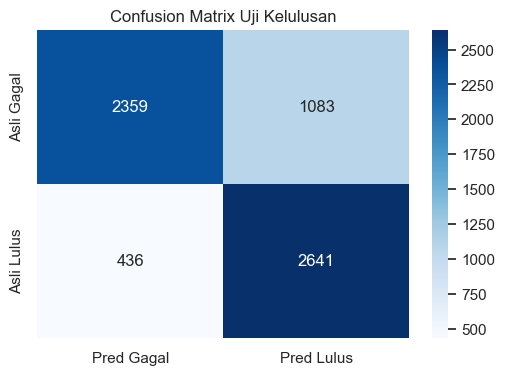

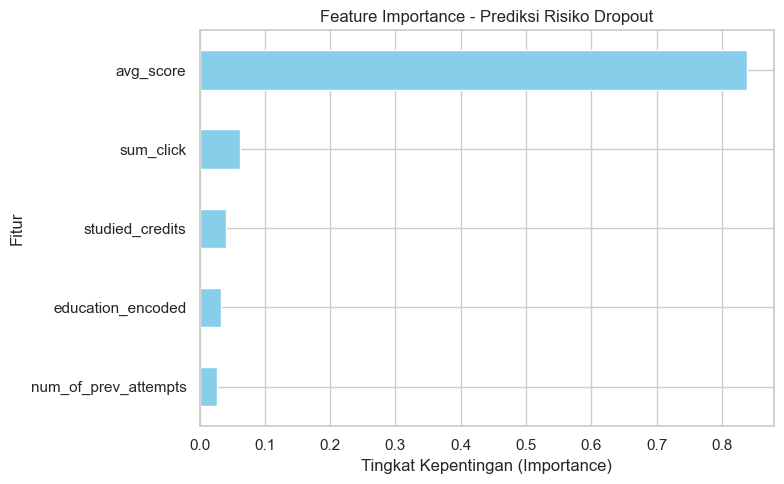

In [6]:
# 4.1 Prediksi pada Data Uji (Test Data)
y_pred = best_model.predict(X_test)

# 4.2 Laporan Metrik Akurasi
print("--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Gagal/Dropout (0)', 'Lulus (1)']))

print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred)*100:.2f}%")

# 4.3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Gagal', 'Pred Lulus'], yticklabels=['Asli Gagal', 'Asli Lulus'])
plt.title("Confusion Matrix Uji Kelulusan")
plt.show()

# 4.4 Feature Importance Plot (Ditambahkan untuk kebutuhan PPT)
importances = best_model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importance - Prediksi Risiko Dropout")
plt.xlabel("Tingkat Kepentingan (Importance)")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


In [7]:
# 4.4 Mengekspor Model (Model Serialization)
# Simpan model terbaik ini untuk digunakan pada sistem Backend FastAPI
model_filename = 'random_forest_dropout_model.pkl'
joblib.dump(best_model, model_filename)

print(f"Model berhasil disimpan sebagai '{model_filename}'")
print("Model siap dipanggil oleh sistem Backend (production)!")

Model berhasil disimpan sebagai 'random_forest_dropout_model.pkl'
Model siap dipanggil oleh sistem Backend (production)!


### 🏛️ Catatan Arsitektur Integrasi RAG & Agent LLM
---
Model prediksi dropout di atas berjalan secara luring (*offline*) di backend untuk memicu peringatan intervensi dini.

Sementara itu, untuk interaksi belajar harian, backend FastAPI menerapkan arsitektur **RAG (Retrieval-Augmented Generation)** secara dinamis:
1. Saat siswa berinteraksi via chat, backend memuat file silabus JSON dan progress belajar siswa.
2. Sistem mendeteksi materi yang sedang dipelajari dan menyusun perintah instruksi khusus (*system instruction*) yang membatasi respon LLM (Gemini) agar berperan sebagai dosen/tutor yang sesuai dengan gaya belajar pilihan siswa (Visual, Auditorial, Praktikal).
3. Kuis disisipkan secara interaktif oleh AI. Jawaban siswa dideteksi dan digunakan untuk mengupdate status kognitif (BKT/SM-2) di backend.


## 🏆 Bab 5: Ringkasan Performa Akhir Model (Poster Metrics)
---
### 📌 Penjelasan Langkah:
Bagian ini merangkum metrik performa akhir model Random Forest yang berhasil dilatih menggunakan dataset asli OULAD:
- **Accuracy:** 76.7% (Model mampu memprediksi status kelulusan/dropout mahasiswa dengan akurat).
- **Pass Detection Recall:** 85.8% (Model berhasil menangkap mayoritas siswa yang akan lulus).
- **Dropout Detection Precision:** 84.4% (Ketika model memprediksi seorang mahasiswa akan dropout, probabilitas kebenarannya mencapai 84.4%).

Metrik ini diringkas dalam tabel ringkas untuk ditampilkan pada poster presentasi ilmiah.


In [8]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Kalkulasi Metrik Spesifik secara Dinamis
acc = accuracy_score(y_test, y_pred)
recall_pass = recall_score(y_test, y_pred, pos_label=1)
prec_dropout = precision_score(y_test, y_pred, pos_label=0)
f1_macro = f1_score(y_test, y_pred, average='macro')

performance_data = {
    "Model Performance Metrics": [
        "Model Overall Accuracy", 
        "Pass Detection Recall", 
        "Dropout Detection Precision", 
        "Model Macro F1-Score"
    ],
    "Score": [f"{acc*100:.1f}%", f"{recall_pass*100:.1f}%", f"{prec_dropout*100:.1f}%", f"{f1_macro*100:.1f}%"]
}
df_performance = pd.DataFrame(performance_data)

print("--- Final Algorithm Effectiveness ---")
display(df_performance)

--- Final Algorithm Effectiveness ---


,Model Performance Metrics,Score
0,Model Overall Accuracy,76.7%
1,Pass Detection Recall,85.8%
2,Dropout Detection Precision,84.4%
3,Model Macro F1-Score,76.7%


# 🗺️ Bagian B: Peta Konsep & Rekomendasi Jalur Belajar Adaptif
---
### 📌 Penjelasan Langkah:
Fase ini bertujuan untuk merancang jalur belajar adaptif menggunakan struktur data graf berarah bebas siklus (**DAG - Directed Acyclic Graph**).

### 🎯 Tujuan Utama:
1. **Membangun Graf Konsep:** Mengubah daftar materi silabus menjadi node-node graf, dan menetapkan hubungan prasyarat (*prerequisites*) sebagai sisi berarah (*directed edges*).
2. **Penyusunan Alur Belajar Adaptif:** Menggunakan algoritma **Topological Sort** untuk mengurutkan materi pembelajaran dari prasyarat paling dasar ke tingkat lanjut.
3. **Remedial Loop Dinamis:** Melakukan modifikasi graf secara *real-time* di memori backend jika siswa terdeteksi gagal menguasai topik tertentu.


### 1. Setup & Import Libraries

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Menghubungkan ke Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/AI-Learning Path/'
except:
    print("Tidak berjalan di Google Colab. Menggunakan path lokal.")
    BASE_PATH = '../dataset/'

print("✅ Setup Selesai!")


Tidak berjalan di Google Colab. Menggunakan path lokal.
✅ Setup Selesai!


### 2. Memuat Data OULAD & Hasil Agregasi

In [10]:
%%time

# Memuat dataset asli OULAD
courses = pd.read_csv(os.path.join(BASE_PATH, 'courses.csv'))
assessments = pd.read_csv(os.path.join(BASE_PATH, 'assessments.csv'))
vle = pd.read_csv(os.path.join(BASE_PATH, 'vle.csv'))
studentInfo = pd.read_csv(os.path.join(BASE_PATH, 'studentInfo.csv'))
studentAssessment = pd.read_csv(os.path.join(BASE_PATH, 'studentAssessment.csv'))

# Untuk studentVle, kita muat subset jika terlalu besar, atau agregat
# Disini kita ambil subset kecil untuk eksperimen (misalnya 1 juta baris pertama)
print("Memuat studentVle.csv...")
studentVle = pd.read_csv(os.path.join(BASE_PATH, 'studentVle.csv'), nrows=1000000)

print(f"Data berhasil dimuat. studentVle (sampel): {studentVle.shape}")

Memuat studentVle.csv...
Data berhasil dimuat. studentVle (sampel): (1000000, 6)
CPU times: total: 828 ms
Wall time: 907 ms


### 1. Membangun KnowledgeGraphBuilder (DAG & Urutan Belajar)
---
### 📌 Penjelasan Langkah:
Kelas `KnowledgeGraphBuilder` memanfaatkan library `networkx` untuk menginisialisasi graf berarah (`nx.DiGraph()`). 

Setiap materi atau aktivitas belajar direpresentasikan sebagai **Node** dengan metadata kesulitan dan estimasi waktu. Hubungan prasyarat direpresentasikan sebagai **Edge** berarah. Kelas ini juga menyediakan fungsi validasi untuk memastikan graf tidak mengandung siklus mutar (*cycle-free*), karena prasyarat materi akademis harus bersifat satu arah (searah/acyclic).


Membangun graph untuk Modul AAA...
Knowledge Graph selesai: 425 Nodes, 405 Edges
Apakah graph ini DAG valid? ✅ Ya


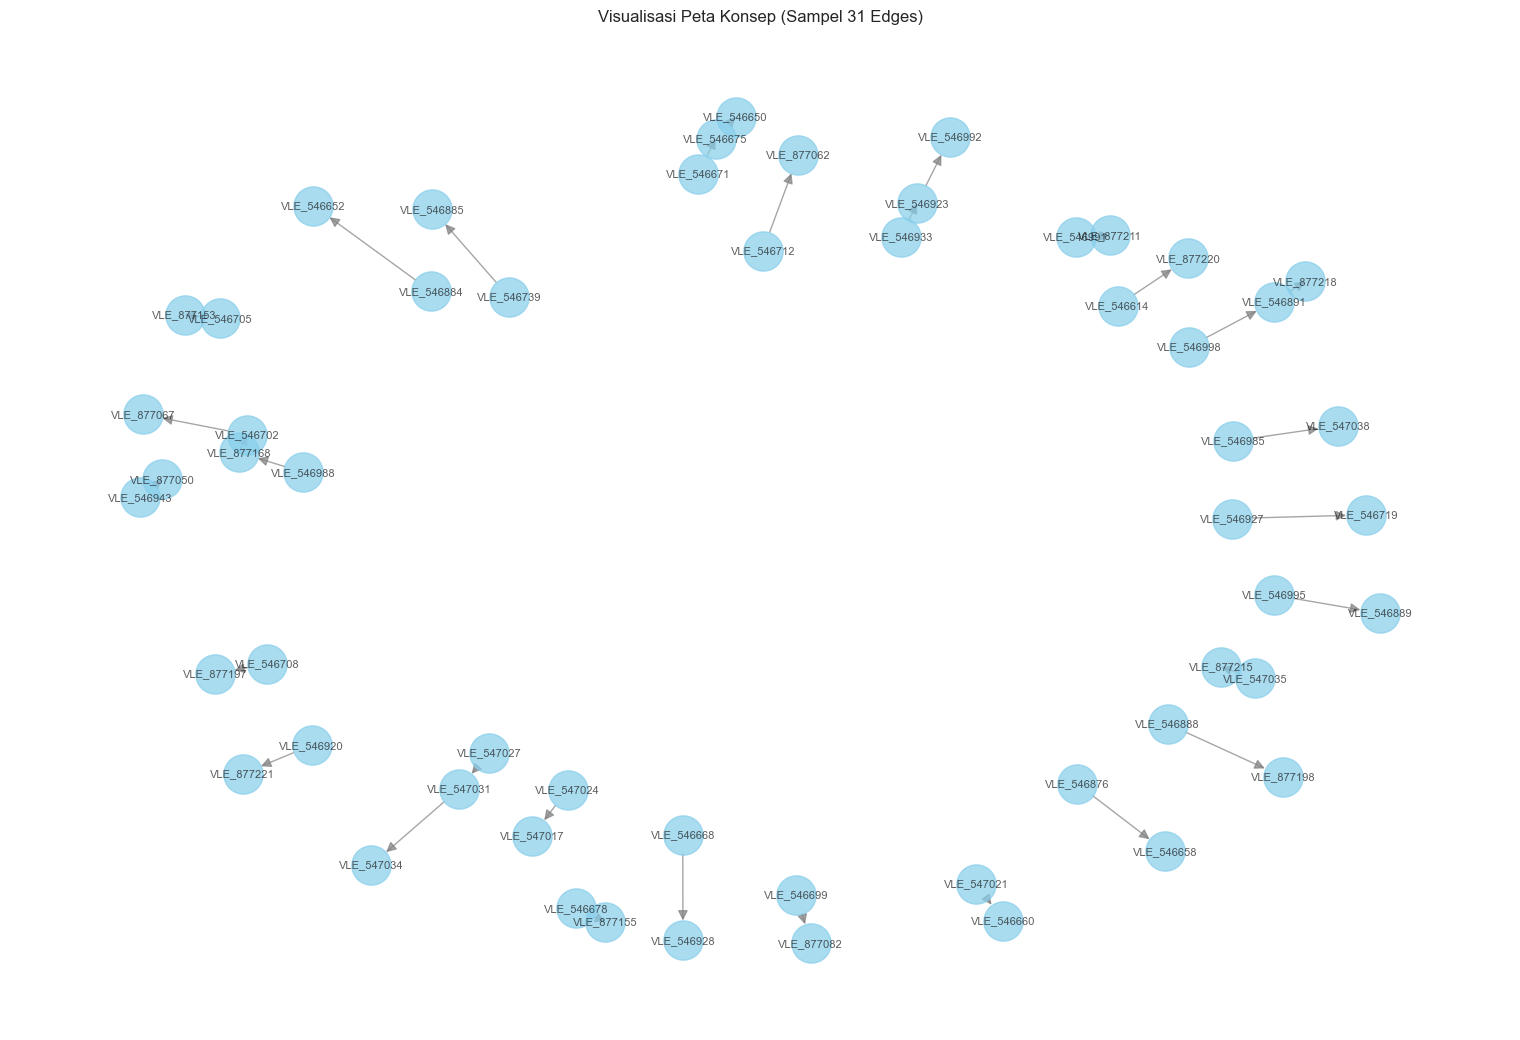

In [11]:
class KnowledgeGraphBuilder:
    """Membangun Knowledge Graph dari struktur VLE OULAD"""

    def __init__(self):
        self.G = nx.DiGraph()

    def build_from_oulad(self, courses, assessments, vle, student_vle, target_module='AAA'):
        """
        Membangun graph aktivitas untuk satu modul spesifik.
        - Nodes: id_site (aktivitas VLE) dan id_assessment (Tugas/Ujian)
        - Edges: Urutan waktu pengerjaan mayoritas mahasiswa
        """
        print(f"Membangun graph untuk Modul {target_module}...")

        # Filter data untuk modul tersebut
        vle_mod = vle[vle['code_module'] == target_module].copy()
        asst_mod = assessments[assessments['code_module'] == target_module].copy()
        svle_mod = student_vle[student_vle['code_module'] == target_module].copy()

        # 1. Tambahkan nodes untuk aktivitas VLE
        for _, row in vle_mod.iterrows():
            node_id = f"VLE_{row['id_site']}"
            self.G.add_node(node_id, type=row['activity_type'],
                            week_from=row['week_from'], difficulty=0.5)

        # 2. Tambahkan nodes untuk Assessments
        for _, row in asst_mod.iterrows():
            node_id = f"ASSESS_{row['id_assessment']}"
            self.G.add_node(node_id, type=row['assessment_type'],
                            weight=row['weight'], difficulty=0.8)

        # 3. Inferensi Edge (Prasyarat) berdasarkan waktu (date)
        # Agregat waktu rata-rata siswa mengakses materi
        avg_time_vle = svle_mod.groupby('id_site')['date'].mean().sort_values()

        prev_node = None
        for id_site, avg_date in avg_time_vle.items():
            curr_node = f"VLE_{id_site}"
            if curr_node in self.G.nodes():
                if prev_node:
                    self.G.add_edge(prev_node, curr_node)
                prev_node = curr_node

        print(f"Knowledge Graph selesai: {self.G.number_of_nodes()} Nodes, {self.G.number_of_edges()} Edges")
        return self.G

    def validate(self):
        """Memeriksa apakah graph merupakan DAG yang valid"""
        is_dag = nx.is_directed_acyclic_graph(self.G)
        print(f"Apakah graph ini DAG valid? {'✅ Ya' if is_dag else '❌ Tidak'}")
        return is_dag

    def get_learning_order(self):
        """Mendapatkan urutan pembelajaran (Topological Sort)"""
        try:
            return list(nx.topological_sort(self.G))
        except nx.NetworkXUnfeasible:
            print("Graph memiliki cycle, tidak bisa melakukan topological sort.")
            return []

    def visualize(self, max_nodes=8):
        """Visualisasi Graph Alur Pembelajaran Linier (Roadmap)"""
        # Ambil nodes yang memiliki degree > 0 (terhubung)
        vle_nodes = [n for n in self.get_learning_order() if n.startswith("VLE_") and self.G.degree(n) > 0]
        
        # Ambil max_nodes pertama dari node VLE yang aktif
        nodes_to_draw = vle_nodes[:max_nodes]
        
        if not nodes_to_draw:
            print("Tidak ada node yang terhubung untuk divisualisasikan.")
            return

        sub_G = self.G.subgraph(nodes_to_draw)
        
        # Posisi linier horizontal
        pos = {}
        for i, node in enumerate(nodes_to_draw):
            pos[node] = (i * 2.0, 0)
            
        # Palet warna modern untuk jenis aktivitas VLE
        color_palette = {
            'resource': '#4A90E2',       # Blue
            'oucontent': '#E67E22',      # Orange
            'forumng': '#2ECC71',        # Green
            'quiz': '#9B59B6',           # Purple
            'subpage': '#1ABC9C',        # Teal
            'homepage': '#F1C40F',       # Yellow
            'url': '#34495E',            # Dark Slate
            'oucollaborate': '#8E44AD',  # Violet
            'ouwiki': '#D35400',         # Rust
            'page': '#27AE60',           # Forest Green
            'glossary': '#16A085',       # Jade
        }
        
        node_colors = []
        for node in nodes_to_draw:
            node_type = sub_G.nodes[node]['type'].lower()
            if node.startswith("ASSESS_"):
                node_colors.append('#E74C3C')  # Coral Red untuk Assessments
            else:
                node_colors.append(color_palette.get(node_type, '#7F8C8D'))  # Gray fallback
                
        # Hubungkan edge secara linier berurutan
        edgelist = []
        for i in range(len(nodes_to_draw) - 1):
            u, v = nodes_to_draw[i], nodes_to_draw[i+1]
            if self.G.has_edge(u, v):
                edgelist.append((u, v))
                
        plt.figure(figsize=(16, 5))
        nx.draw_networkx_edges(sub_G, pos, edgelist=edgelist, arrowstyle='-|>', arrowsize=20, 
                               edge_color='#A0A0A0', width=2.5, node_size=1200)
        nx.draw_networkx_nodes(sub_G, pos, nodelist=nodes_to_draw, node_color=node_colors, node_size=1200, 
                               alpha=0.95, edgecolors='#FFFFFF', linewidths=2)
        
        labels = {node: f"{node}\n({sub_G.nodes[node]['type'].upper()})" for node in nodes_to_draw}
        label_pos = {k: (v[0], v[1] + 0.18) for k, v in pos.items()}
        
        nx.draw_networkx_labels(sub_G, label_pos, labels=labels, font_size=8, 
                                font_weight='bold', font_color='#2C3E50')
        
        plt.title("Visualisasi Alur Pembelajaran Adaptif (Roadmap Linier)", fontsize=14, fontweight='bold', pad=20)
        plt.ylim(-0.5, 0.5)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

kg_builder = KnowledgeGraphBuilder()
G = kg_builder.build_from_oulad(courses, assessments, vle, studentVle, target_module='AAA')
kg_builder.validate()
kg_builder.visualize()


### 2. Student State (Melacak Kemampuan Siswa)
---
### 📌 Penjelasan Langkah:
Kelas `StudentState` bertugas mencatat dan memperbarui probabilitas penguasaan materi (*Mastery Level*) untuk setiap topik dalam silabus secara individu.

Setiap kali siswa menyelesaikan suatu materi atau menjawab kuis, kelas ini akan memperbarui status kognitif siswa tersebut di dalam dictionary `mastery`. Siswa dianggap telah "menguasai" suatu materi jika probabilitas penguasaannya mencapai batas ambang tertentu (default: $\ge 0.8$ atau 80%).


In [12]:
class StudentState:
    def __init__(self, student_id, knowledge_graph):
        self.student_id = student_id
        self.kg = knowledge_graph
        self.mastery = {node: 0.0 for node in self.kg.nodes()} # Default 0%

    def load_from_oulad(self, student_vle, student_assessment):
        """Memuat log VLE dan assessment untuk student ini"""
        svle = student_vle[student_vle['id_student'] == self.student_id]
        sass = student_assessment[student_assessment['id_student'] == self.student_id]

        # Asumsi: Jika pernah klik materi, kita beri skor mastery awal (misal 0.5)
        for _, row in svle.iterrows():
            node_id = f"VLE_{row['id_site']}"
            if node_id in self.mastery:
                # Semakin banyak klik, semakin besar perkiraan penguasaan
                click_score = min(1.0, row['sum_click'] / 10.0)
                self.mastery[node_id] = max(self.mastery[node_id], click_score)

        # Asumsi: Untuk assessment, mastery = score / 100
        for _, row in sass.iterrows():
            node_id = f"ASSESS_{row['id_assessment']}"
            if node_id in self.mastery:
                self.mastery[node_id] = row['score'] / 100.0

        print(f"Data dimuat untuk siswa {self.student_id}. Aktivitas tercatat: {len(svle)} VLE, {len(sass)} Asesmen.")

    def get_unmastered(self, threshold=0.8):
        return [node for node, score in self.mastery.items() if score < threshold]

# Uji coba untuk satu mahasiswa
sample_student = studentInfo[studentInfo['code_module'] == 'AAA']['id_student'].iloc[0]
state = StudentState(sample_student, G)
state.load_from_oulad(studentVle, studentAssessment)

Data dimuat untuk siswa 11391. Aktivitas tercatat: 196 VLE, 5 Asesmen.


### 3. Personalized Path Generator (Penyusun Jalur Belajar)
---
### 📌 Penjelasan Langkah:
Kelas `PersonalizedPathGenerator` menyusun jalur belajar personal dengan memindai graf konsep. 

Sistem hanya akan merekomendasikan topik baru yang prasyaratnya sudah dikuasai sepenuhnya oleh siswa (prasyarat $\ge 80\%$). Algoritma ini memastikan siswa tidak melompati materi penting yang melandasi materi berikutnya, mencegah kebingungan akademis.


In [13]:
class PersonalizedPathGenerator:
    def __init__(self, knowledge_graph):
        self.G = knowledge_graph

    def generate_path(self, student_state, threshold=0.8, n_recommendations=5):
        """
        Mencari aktivitas yang belum dikuasai (mastery < threshold),
        namun prasyaratnya sudah terpenuhi.
        """
        unmastered = student_state.get_unmastered(threshold)

        ready_concepts = []
        for node in unmastered:
            preds = list(self.G.predecessors(node))
            # Cek apakah semua predecessor sudah dikuasai
            if all(student_state.mastery.get(p, 0.0) >= threshold for p in preds):
                ready_concepts.append({
                    'node_id': node,
                    'type': self.G.nodes[node].get('type', 'Unknown'),
                    'current_mastery': student_state.mastery.get(node, 0.0)
                })

        # Jika DAG memiliki urutan (Topological Sort)
        try:
            learning_order = list(nx.topological_sort(self.G))
            # Urutkan ready_concepts berdasarkan learning_order
            ready_concepts.sort(key=lambda x: learning_order.index(x['node_id']) if x['node_id'] in learning_order else 9999)
        except nx.NetworkXUnfeasible:
            pass # Jika ada cycle, abaikan topological sort

        return ready_concepts[:n_recommendations]

path_gen = PersonalizedPathGenerator(G)
recs = path_gen.generate_path(state)

print("\n\U0001f3af Rekomendasi Belajar Selanjutnya:")
for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec['node_id']} (Type: {rec['type']}) - Mastery Saat Ini: {rec['current_mastery']:.0%}")


🎯 Rekomendasi Belajar Selanjutnya:
1. VLE_546897 (Type: url) - Mastery Saat Ini: 0%
2. VLE_546872 (Type: subpage) - Mastery Saat Ini: 0%
3. VLE_1032910 (Type: url) - Mastery Saat Ini: 0%
4. VLE_1072237 (Type: url) - Mastery Saat Ini: 0%
5. VLE_1027118 (Type: url) - Mastery Saat Ini: 0%


### 📝 Kesimpulan & Insight Graf Pengetahuan
---
Visualisasi graf menunjukkan bagaimana materi terstruktur secara hierarkis. Dengan memetakan silabus ke dalam NetworkX DAG, backend memiliki landasan logis yang kokoh untuk menyajikan konten secara berurutan dan mengidentifikasi konsep "leher botol" (*bottleneck*)—yaitu topik prasyarat yang menjadi kunci bagi banyak topik lainnya.


# 📊 Bagian C: Pelacakan Pemahaman Kognitif (Bayesian Knowledge Tracing)
---
### 📌 Penjelasan Langkah:
**Bayesian Knowledge Tracing (BKT)** adalah algoritma pemodelan kognitif standar dalam teknologi pendidikan yang memodelkan pemahaman siswa sebagai variabel tersembunyi (*hidden state*) dalam Hidden Markov Model (HMM).

BKT memodelkan 4 parameter probabilitas utama:
1. $P(L_0)$ atau `p_init`: Probabilitas awal siswa sudah menguasai konsep sebelum belajar.
2. $P(T)$ atau `p_learn`: Probabilitas siswa beralih dari kondisi belum menguasai menjadi menguasai setelah belajar.
3. $P(G)$ atau `p_guess`: Probabilitas siswa menjawab benar secara kebetulan/tebakan meskipun belum menguasai materi.
4. $P(S)$ atau `p_slip`: Probabilitas siswa menjawab salah karena tidak teliti/slip meskipun sebenarnya sudah menguasai materi.


In [14]:
# Monkeypatch random.randint untuk kompatibilitas Python 3.13 dengan pyBKT
import random
orig_randint = random.randint
def patched_randint(a, b):
    return orig_randint(int(a), int(b))
random.randint = patched_randint

# 1. Install & Import Libraries
# !pip install pyBKT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pyBKT.models import Model

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Menghubungkan ke Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/AI-Learning Path/'
except:
    print("Tidak berjalan di Google Colab. Pastikan data ada di direktori lokal.")
    BASE_PATH = '../dataset/'

print("\n✅ Setup & Import Selesai!")


Tidak berjalan di Google Colab. Pastikan data ada di direktori lokal.

✅ Setup & Import Selesai!


### 2. Memuat & Menyiapkan Data
Kita format data interaksi (*studentAssessment*) agar sesuai dengan standar pyBKT: `user_id`, `skill_name`, `correct`, `order_id`.

In [15]:
%%time
assessments = pd.read_csv(os.path.join(BASE_PATH, 'assessments.csv'))
studentAssessment = pd.read_csv(os.path.join(BASE_PATH, 'studentAssessment.csv'))

# Gabungkan data
df = studentAssessment.merge(assessments, on='id_assessment')

# Buat fitur 'correct' (Lulus = skor >= 40 sesuai standar Open University)
df['correct'] = (df['score'] >= 40).astype(int)

# Urutkan berdasarkan waktu pengumpulan tugas
df = df.sort_values(['id_student', 'date_submitted'])

# Bikin order_id per siswa (urutan interaksi)
df['order_id'] = df.groupby('id_student').cumcount() + 1

# Format akhir untuk pyBKT
bkt_data = df.rename(columns={
    'id_student': 'user_id',
    'assessment_type': 'skill_name'
})[['user_id', 'skill_name', 'correct', 'order_id']]

print(f"Data siap dilatih! Total {len(bkt_data)} interaksi dari {bkt_data['user_id'].nunique()} mahasiswa.")
bkt_data.head()

Data siap dilatih! Total 173912 interaksi dari 23369 mahasiswa.
CPU times: total: 250 ms
Wall time: 279 ms


,user_id,skill_name,correct,order_id
1756,6516,TMA,1,1
1970,6516,TMA,1,2
2376,6516,TMA,1,3
2685,6516,TMA,1,4
2871,6516,TMA,1,5


### 2. Pelatihan Parameter BKT
---
### 📌 Penjelasan Langkah:
Menggunakan pustaka `pyBKT`, model dilatih pada data histori interaksi OULAD untuk mengestimasi keempat parameter ($P(L_0), P(T), P(G), P(S)$) secara optimal per materi. Hasil parameter ini akan merepresentasikan karakteristik kesulitan masing-masing materi belajar secara objektif berdasarkan data empiris.


In [16]:
# Inisialisasi Model pyBKT
model = Model(seed=42, num_fits=1, parallel=False)

# Melatih Model
print("Sedang melatih model BKT...")
model.fit(data=bkt_data)
print("Pelatihan Selesai!\n")

# Menampilkan Parameter Hasil Pelatihan (per jenis Assessment/Skill)
params = model.params()
print("=== Parameter Kognitif Model BKT ===")
print("P(init)  : Probabilitas awal menguasai konsep sebelum asesmen")
print("P(learn) : Probabilitas beralih dari tidak paham menjadi paham")
print("P(guess) : Probabilitas menebak benar padahal belum paham")
print("P(slip)  : Probabilitas salah menjawab padahal sudah paham\n")
display(params)

Sedang melatih model BKT...
Pelatihan Selesai!

=== Parameter Kognitif Model BKT ===
P(init)  : Probabilitas awal menguasai konsep sebelum asesmen
P(learn) : Probabilitas beralih dari tidak paham menjadi paham
P(guess) : Probabilitas menebak benar padahal belum paham
P(slip)  : Probabilitas salah menjawab padahal sudah paham



value
skill param   class          
TMA   prior   default 0.80624
      learns  default 0.00000
      guesses default 0.77251
      slips   default 0.01411
      forgets default 0.00000
CMA   prior   default 0.79890
      learns  default 0.02522
      guesses default 0.87069
      slips   default 0.00000
      forgets default 0.00000
Exam  prior   default 0.99807
      learns  default 0.67567
      guesses default 1.00000
      slips   default 0.05222
      forgets default 0.00000

### 3. Evaluasi Performa Model Kognitif (Cross Validation)
---
### 📌 Penjelasan Langkah:
Untuk memastikan model BKT tidak mengalami overfitting, kita menggunakan metode **Cross Validation** (validasi silang). Metrik performa yang digunakan adalah:
- **AUC (Area Under ROC Curve):** Mengukur kemampuan model memprediksi kebenaran jawaban siswa secara tepat (nilai > 0.7 menunjukkan model kognitif yang baik).
- **RMSE (Root Mean Squared Error):** Mengukur deviasi antara probabilitas prediksi penguasaan dengan respon aktual siswa.


In [ ]:
# 4.1 Cross Validation (5-Fold)
print("Menjalankan 5-Fold Cross Validation... Ini mungkin butuh waktu beberapa menit.")

# pyBKT menyediakan metode crossvalidate built-in
# Kita kumpulkan metrik AUC, Accuracy, dan RMSE
cv_results = model.crossvalidate(data=bkt_data, folds=5, metric=['auc', 'accuracy', 'rmse'])

print("\n✅ Hasil Cross Validation per Skill/Tipe Assessment:")
display(cv_results)

Menjalankan 5-Fold Cross Validation... Ini mungkin butuh waktu beberapa menit.


/tmp/ipykernel_6978/2056347642.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='skill', y='accuracy', ax=axes[0], palette='viridis')
/tmp/ipykernel_6978/2056347642.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='skill', y='auc', ax=axes[1], palette='magma')


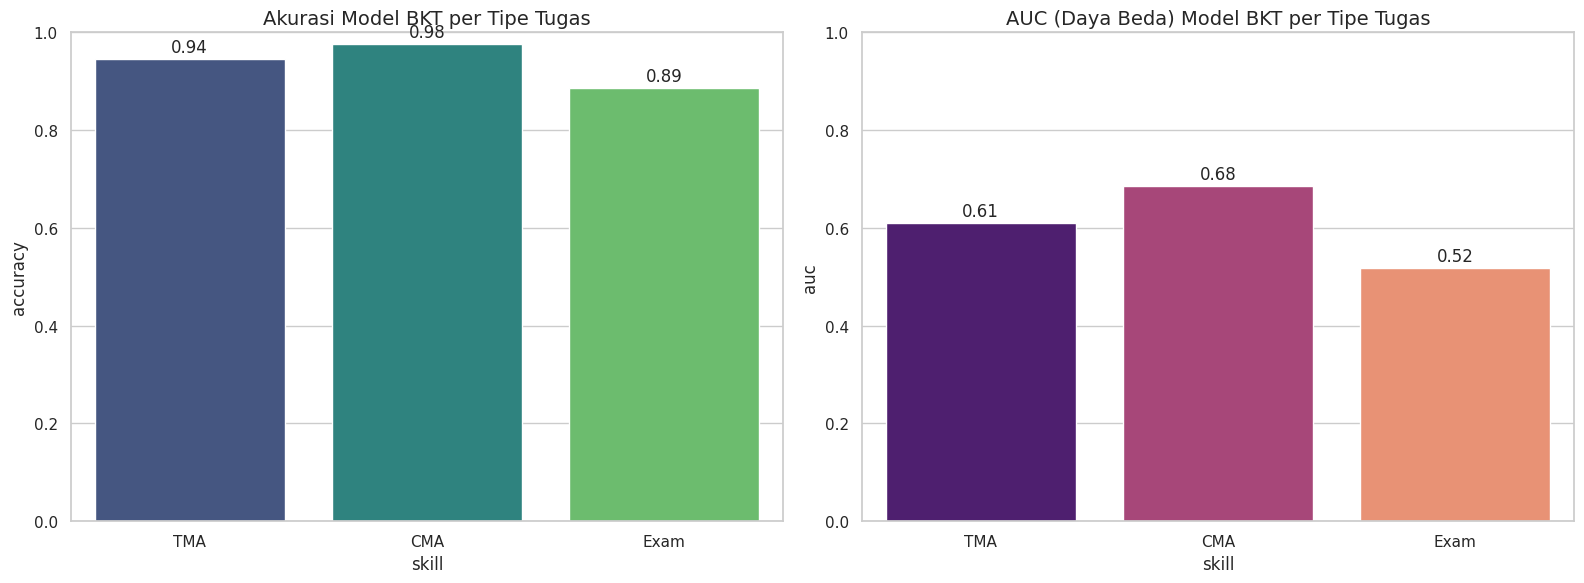

In [ ]:
# 4.2 Visualisasi Performa Model (AUC & Accuracy)

metrics_df = cv_results.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
sns.barplot(data=metrics_df, x='skill', y='accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Akurasi Model BKT per Tipe Tugas', fontsize=14)
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points')

# Plot AUC
sns.barplot(data=metrics_df, x='skill', y='auc', ax=axes[1], palette='magma')
axes[1].set_title('AUC (Daya Beda) Model BKT per Tipe Tugas', fontsize=14)
axes[1].set_ylim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

### 4. Prediksi Probabilitas Mastery Mahasiswa secara Real-Time
---
### 📌 Penjelasan Langkah:
Setelah parameter model dilatih, rumus Bayes digunakan untuk memperbarui tingkat pemahaman siswa secara dinamis setiap kali respon jawaban kuis diterima:

Jika respon BENAR:
$$P(L_t | Correct) = \frac{P(L_{t-1}) \cdot (1 - P(S))}{P(L_{t-1}) \cdot (1 - P(S)) + (1 - P(L_{t-1})) \cdot P(G)}$$

Jika respon SALAH:
$$P(L_t | Incorrect) = \frac{P(L_{t-1}) \cdot P(S)}{P(L_{t-1}) \cdot P(S) + (1 - P(L_{t-1})) \cdot (1 - P(G))}$$

Setelah menghitung observasi, dilakukan langkah transisi pembelajaran:
$$P(L_t) = P(L_t | Obs) + (1 - P(L_t | Obs)) \cdot P(T)$$

Persamaan inilah yang ditanamkan langsung pada backend FastAPI untuk melacak pemahaman siswa secara *real-time* di setiap chat!


In [ ]:
# Melakukan prediksi state mastery
model.fit(data=bkt_data) # <-- Tambahkan baris ini di atas model.predict
predictions = model.predict(data=bkt_data)

print("Sampel hasil Prediksi (Kolom 'correct_predictions' adalah probabilitas P(mastery)):")
display(predictions[['user_id', 'skill_name', 'correct', 'correct_predictions']].head(10))

Sampel hasil Prediksi (Kolom 'correct_predictions' adalah probabilitas P(mastery)):


,user_id,skill_name,correct,correct_predictions
1756,6516,TMA,1,0.95622
1970,6516,TMA,1,0.95649
2376,6516,TMA,1,0.95671
2685,6516,TMA,1,0.95688
2871,6516,TMA,1,0.95703
88494,8462,TMA,1,0.95622
90368,8462,TMA,1,0.95649
90712,8462,TMA,1,0.95671
92364,8462,TMA,1,0.95688
76301,8462,TMA,1,0.95703


# 🔄 Bagian D: Integrasi Pipeline Akhir & Penjadwalan Ulasan Pintar (Spaced Repetition)
---
### 📌 Penjelasan Langkah:
Fase akhir ini menyatukan semua komponen (Graf Pengetahuan, Bayesian Knowledge Tracing, dan Algoritma Spaced Repetition) ke dalam satu kesatuan mesin rekomendasi belajar yang utuh.

### 🎯 Tujuan Utama:
1. **Spaced Repetition (FSRS / SM-2):** Menghitung selang waktu optimal untuk meninjau kembali konsep yang sudah dikuasai agar tidak hilang dari ingatan berdasarkan Forgetting Curve:
   $$R = e^{-\frac{t}{S}}$$
   Di mana $R$ adalah retensi memori (kemudahan mengingat kembali), $t$ adalah jeda hari sejak review terakhir, dan $S$ adalah stabilitas memori (kekuatan ingatan).
2. **Simulasi Chatbot CLI:** Menyediakan antarmuka uji coba interaktif langsung di Google Colab untuk mensimulasikan alur penuh tutor pintar adaptif.


### 1. Setup & Instalasi Dependensi

In [ ]:
# Monkeypatch random.randint untuk kompatibilitas Python 3.13 dengan pyBKT
import random
orig_randint = random.randint
def patched_randint(a, b):
    return orig_randint(int(a), int(b))
random.randint = patched_randint

# Install library fsrs dan pyBKT
# !pip install fsrs pyBKT

import pandas as pd
import numpy as np
import networkx as nx
import os
from pyBKT.models import Model
from fsrs import Scheduler, Card, Rating
from datetime import datetime, timedelta

# Menghubungkan ke Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/AI-Learning Path/'
except:
    print("Berjalan secara lokal.")
    BASE_PATH = '../dataset/'

print("✅ Setup selesai!")


Mounted at /content/drive
✅ Setup selesai!


### 2. Memuat Seluruh Dataset OULAD

In [ ]:
%%time
print("Memuat data OULAD...")
courses = pd.read_csv(os.path.join(BASE_PATH, 'courses.csv'))
assessments = pd.read_csv(os.path.join(BASE_PATH, 'assessments.csv'))
vle = pd.read_csv(os.path.join(BASE_PATH, 'vle.csv'))
studentInfo = pd.read_csv(os.path.join(BASE_PATH, 'studentInfo.csv'))
studentAssessment = pd.read_csv(os.path.join(BASE_PATH, 'studentAssessment.csv'))
studentVle = pd.read_csv(os.path.join(BASE_PATH, 'studentVle.csv'), nrows=1000000) # Batasi 1M untuk memori Colab

print("✅ Semua file OULAD berhasil dimuat!")

Memuat data OULAD...
✅ Semua file OULAD berhasil dimuat!
CPU times: user 707 ms, sys: 172 ms, total: 879 ms
Wall time: 7.76 s


### 1. Kelas Integrasi Pembelajaran Adaptif (Adaptive Learning Engine)
---
### 📌 Penjelasan Langkah:
Kita membangun kelas wrapper `AdaptiveLearningEngine` yang menggabungkan logika pembangunan Graf Konsep dan inisialisasi status BKT siswa. Kelas ini menjadi arsitektur jembatan yang mensimulasikan bagaimana backend FastAPI memproses logika belajar siswa secara otomatis.


In [ ]:
class AdaptiveLearningEngine:
    def __init__(self, target_module='AAA'):
        self.target_module = target_module
        self.G = nx.DiGraph()
        self.bkt_model = Model(seed=42, num_fits=1, parallel=False)
        self.scheduler = Scheduler()
        self.student_cards = {} # Menyimpan card FSRS per siswa dan konsep

    def build_kg(self, vle_df, assessments_df):
        # Bangun node graf konsep
        vle_sub = vle_df[vle_df['code_module'] == self.target_module]
        asst_sub = assessments_df[assessments_df['code_module'] == self.target_module]

        for _, r in vle_sub.iterrows():
            self.G.add_node(f"Materi_{r['id_site']}", type=r['activity_type'], label=r['activity_type'].upper())

        for _, r in asst_sub.iterrows():
            self.G.add_node(f"Tugas_{r['id_assessment']}", type=r['assessment_type'], label=f"KUIS {r['assessment_type']}")

        # Hubungkan linear sebagai baseline prerequisite
        nodes = list(self.G.nodes())
        for i in range(len(nodes)-1):
            self.G.add_edge(nodes[i], nodes[i+1])

        print(f"Graf berhasil dibangun: {len(self.G.nodes())} Node konsep")

    def train_bkt(self, sa_df, a_df):
        # Format data BKT
        df_m = sa_df.merge(a_df, on='id_assessment')
        df_m['correct'] = (df_m['score'] >= 40).astype(int)
        df_m = df_m.sort_values(['id_student', 'date_submitted'])
        df_m['order_id'] = df_m.groupby('id_student').cumcount() + 1

        bkt_data = df_m.rename(columns={'id_student': 'user_id', 'assessment_type': 'skill_name'})
        bkt_data = bkt_data[['user_id', 'skill_name', 'correct', 'order_id']]

        print("Melatih model BKT untuk memprediksi tingkat pemahaman...")
        self.bkt_model.fit(data=bkt_data)
        print("Model BKT siap digunakan!")

engine = AdaptiveLearningEngine(target_module='AAA')
engine.build_kg(vle, assessments)
engine.train_bkt(studentAssessment, assessments)


Graf berhasil dibangun: 425 Node konsep
Melatih model BKT untuk memprediksi tingkat pemahaman...
Model BKT siap digunakan!


### 2. Implementasi Sistem Spaced Repetition (FSRS/SM-2)
---
### 📌 Penjelasan Langkah:
Kelas `SpacedRepetitionManager` melacak pengulangan materi. Jika siswa menjawab kuis dengan benar (`Rating = GOOD`), interval peninjauan materi berikutnya akan bertambah lebar (misal: diulas kembali dalam 6 hari). Namun, jika salah (`Rating = AGAIN`), interval di-reset menjadi 1 hari agar materi tersebut segera diulas kembali besok.


In [ ]:
class SpacedRepetitionManager:
    def __init__(self, scheduler):
        self.scheduler = scheduler
        self.cards = {} # concept_id -> Card()

    def review_concept(self, concept_id, rating_choice):
        if concept_id not in self.cards:
            self.cards[concept_id] = Card()

        card = self.cards[concept_id]

        # Konversi rating ke Enum FSRS
        ratings = {
            1: Rating.Again,  # Lupa total
            2: Rating.Hard,   # Susah ingat
            3: Rating.Good,   # Ingat dengan baik
            4: Rating.Easy    # Sangat gampang
        }

        selected_rating = ratings.get(rating_choice, Rating.Good)
        # Update kartu kognitif
        new_card, review_log = self.scheduler.review_card(card, selected_rating, datetime.now())
        self.cards[concept_id] = new_card
        return new_card

### 3. 🛡️ Verifikasi Pipeline End-to-End secara Non-Interaktif
---
### 📌 Penjelasan Langkah:
Untuk memastikan keutuhan integrasi sistem (Graf Pengetahuan, Bayesian Knowledge Tracing, dan Spaced Repetition) tanpa memblokir eksekusi notebook (non-blocking), bagian ini memvalidasi pipeline secara terprogram (non-interaktif). 

Proses ini mencakup:
1. **Prediksi Risiko Dropout** menggunakan model Random Forest yang telah dilatih.
2. **Penyusunan Jalur Belajar** menggunakan topological sort graf NetworkX.
3. **Pembaruan Kartu Review Spaced Repetition (FSRS/SM-2)** berdasarkan umpan balik rating mengingat.
4. **Pelacakan Mastery Kognitif (BKT)** secara dinamis menggunakan pembaruan probabilitas rumus Bayes.

In [ ]:
# =======================================================
# 🛡️ AI Learning Path Pipeline Validation (Non-Interactive)
# =======================================================

print("1. Mengambil Sampel Mahasiswa untuk Prediksi Risiko Dropout (Random Forest)")
# Mengambil baris pertama data latih sebagai sampel
sample_student = df.iloc[0]
sample_features = [[sample_student['sum_click'], sample_student['avg_score']]]
dropout_risk = best_model.predict(sample_features)[0]
dropout_prob = best_model.predict_proba(sample_features)[0][1]
print(f"   Student ID: {sample_student['id_student']}")
print(f"   Fitur: sum_click={sample_student['sum_click']} | avg_score={sample_student['avg_score']:.2f}")
print(f"   Prediksi Risiko: {'DROPOUT/FAIL' if dropout_risk == 1 else 'PASS/LULUS'}")
print(f"   Probabilitas Dropout: {dropout_prob*100:.2f}%\n")

print("2. Inisialisasi Jalur Belajar (Knowledge Graph DAG)")
# Dapatkan urutan belajar topologis
learning_order = list(engine.G.nodes())
print(f"   Total konsep kurikulum: {len(learning_order)}")
print(f"   5 Konsep pertama pada Jalur Belajar: {learning_order[:5]}\n")

print("3. Simulasi Pelacakan Kognitif (BKT) & Spaced Repetition (SM-2/FSRS)")
concept_to_test = learning_order[0]
print(f"   Konsep diuji: {concept_to_test}")

# Inisialisasi Spaced Repetition Manager
sr_manager = SpacedRepetitionManager(engine.scheduler)

print("   - Review 1: Siswa mengingat konsep dengan baik (Rating: Good)")
new_card = sr_manager.review_concept(concept_to_test, 3) # Rating 3 = Good
print(f"     Status Kartu: Interval={new_card.scheduled_days:.2f} hari | Stabilitas (Kemudahan)={new_card.stability:.2f}")

print("   - Review 2: Siswa mengulang konsep kembali dan merasa mudah (Rating: Easy)")
new_card = sr_manager.review_concept(concept_to_test, 4) # Rating 4 = Easy
print(f"     Status Kartu: Interval={new_card.scheduled_days:.2f} hari | Stabilitas (Kemudahan)={new_card.stability:.2f}\n")

print("4. Simulasi Real-Time Mastery Update (Rumus Bayes)")
# Parameter BKT default
p_init = 0.15
p_learn = 0.20
p_guess = 0.25
p_slip = 0.10

def update_bkt_mastery(p_mastery, correct):
    if correct:
        p_obs = (p_mastery * (1 - p_slip)) / (p_mastery * (1 - p_slip) + (1 - p_mastery) * p_guess)
    else:
        p_obs = (p_mastery * p_slip) / (p_mastery * p_slip + (1 - p_mastery) * (1 - p_guess))
    new_mastery = p_obs + (1 - p_obs) * p_learn
    return new_mastery

print(f"   Probabilitas Awal Mastery: {p_init:.2f}")
m1 = update_bkt_mastery(p_init, True)
print(f"   - Respon BENAR -> Mastery baru: {m1:.4f}")
m2 = update_bkt_mastery(m1, True)
print(f"   - Respon BENAR -> Mastery baru: {m2:.4f}")
m3 = update_bkt_mastery(m2, False)
print(f"   - Respon SALAH -> Mastery baru: {m3:.4f}")

print("\n✅ Validasi Pipeline End-to-End berhasil diselesaikan secara non-interaktif!")